# Series de tiempo

# **EDA**

## Paso 0: **Setup básico: Imports**

In [51]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pickle
     

## Paso 1: **Lectura de la data**

In [25]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date') # Configuro la fecha como index del df
df.head()


,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


df.index[0] = primera fila del index  
df.index[-1] = última fila del index

In [26]:
print(f"Cantidad de observaciones (ventas): {len(df)}")
print(f"Periodo: {df.index[0].strftime('%d-%m-%Y')} a {df.index[-1].strftime('%d-%m-%Y')}")

Cantidad de observaciones (ventas): 366
Periodo: 03-09-2022 a 03-09-2023


## Paso 2: **Análisis de la serie temporal**

> - ¿Cuál es la tendencia? Incremento o no en le tiempo.
> - ¿Es estacionaria?
> - ¿Existe variabilidad o presencia de ruido?
> - Nota: Un tensor en una serie temporal es la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes...

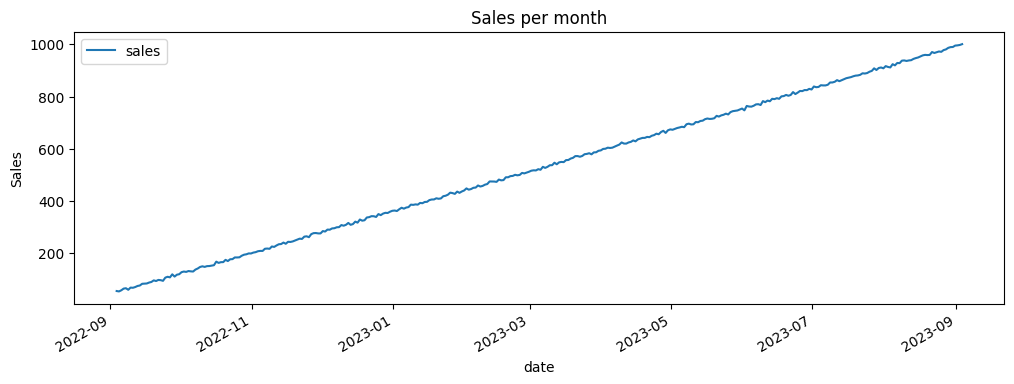

In [27]:
df.plot(figsize=(12, 4), title='Sales per month')
plt.ylabel('Sales')
plt.show()

### Distribución de los componentes de la gráfica

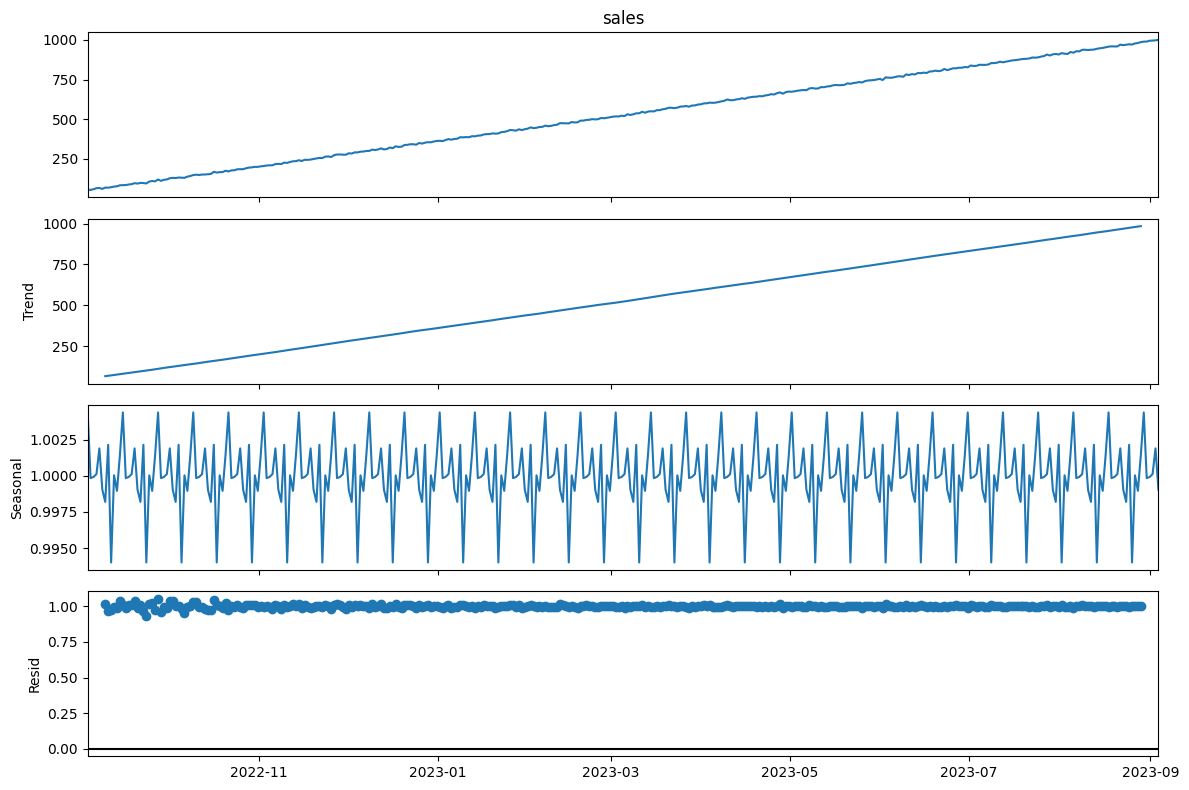

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['sales'], model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

> **Observaciones:**  
> Podemos observar que la cantidad de ventas crece con el tiempo y que cada año se repite un patron similar. Esto nos lleva a hablar de los tres componentes fundamentales de una serie de tiempo. Como la amplitud de las oscilaciones crece con el tiempo, usaremos descomposicion multiplicativa.  
> - Tendencia (p), las ventas crecen con el tiempo. 
> - Estacionalidad(d), son los comportamentos ciclícos en el tiempo. En este caso no se encuentran.  
> - Residuo (q), datos que no siguen la tendencia.  R = 0 (no hay ruido) vs R=1 (mucha variabilidad en la data).
>  
> La descomposicion puede ser:  
> - Aditiva: Serie = Tendencia + Estacionalidad + Residuo (cuando la variacion estacional es constante)  
> - Multiplicativa: Serie = Tendencia x Estacionalidad x Residuo (cuando la variacion estacional crece con la tendencia)

## Preparar datos para train y test

En series de tiempo, la division de datos siempre debe ser cronologica: entrenamos con el pasado y evaluamos con el futuro. Nunca se mezclan datos aleatoriamente como en otros problemas de Machine Learning.

In [30]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]


In [36]:
train

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633
...,...
2023-06-17 17:10:08.079328,800.619737
2023-06-18 17:10:08.079328,801.658496
2023-06-19 17:10:08.079328,806.097320


In [35]:
test

,sales
date,
2023-06-22 17:10:08.079328,816.911750
2023-06-23 17:10:08.079328,809.422692
2023-06-24 17:10:08.079328,814.797630
2023-06-25 17:10:08.079328,821.218893
2023-06-26 17:10:08.079328,820.704134
...,...
2023-08-30 17:10:08.079328,989.600354
2023-08-31 17:10:08.079328,994.987326
2023-09-01 17:10:08.079328,995.814415


In [37]:

print(f"Entrenamiento: {len(train)} observaciones ({train.index[0].strftime('%Y-%m')} a {train.index[-1].strftime('%Y-%m')})")
print(f"Prueba: {len(test)} observaciones ({test.index[0].strftime('%Y-%m')} a {test.index[-1].strftime('%Y-%m')})")


Entrenamiento: 292 observaciones (2022-09 a 2023-06)
Prueba: 74 observaciones (2023-06 a 2023-09)


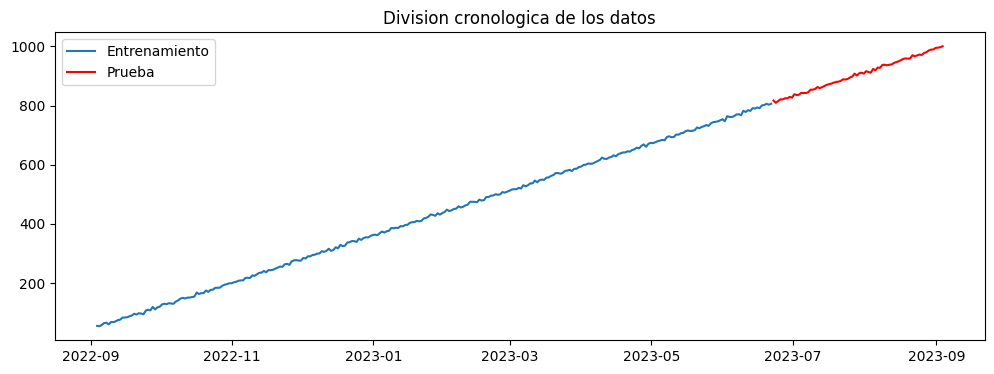

In [41]:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Prueba', color='red')
plt.legend()
plt.title('Division cronologica de los datos')
plt.show()

# **ML**

## Metricas

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def evaluar_modelo(nombre, real, prediccion):
    mae = mean_absolute_error(real, prediccion)
    rmse = np.sqrt(mean_squared_error(real, prediccion))
    mape = np.mean(np.abs((real - prediccion) / real)) * 100
    print(f"{nombre}:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAPE = {mape:.2f}%")
    return {'modelo': nombre, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}


Comparación de modelos

comparacion con ultiom valor que tenemos.

Cada enfoque tiene sus ventajas:

ARIMA: facil de interpretar, funciona bien con pocas datos, ideal para series con patrones claros
LightGBM: muy flexible, permite agregar variables externas facilmente, rapido de entrenar
NHITS: puede capturar patrones complejos automaticamente, muy potente con grandes cantidades de datos

## Prediccion

* **Modelo ARIMA**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_arima = SARIMAX(train['sales'],order=(1, 1, 1),seasonal_order=(1, 1, 1,int(len(test))))
model_arima_fit = model_arima.fit(disp=False)

pred_arima = model_arima_fit.forecast(steps=int(len(test)))
pred_arima.index = test.index

r = evaluar_modelo('ARIMA', test['sales'].values, pred_arima.values)


ARIMA:
  MAE  = 2.42
  RMSE = 3.00
  MAPE = 0.27%


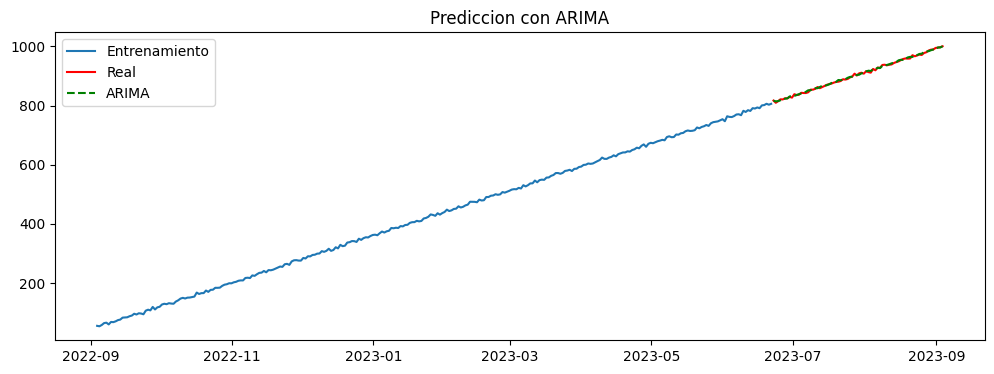

In [50]:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Real', color='red')
plt.plot(test.index, pred_arima, label='ARIMA',color='green', linestyle='--')
plt.legend()
plt.title('Prediccion con ARIMA')
plt.show()

> **Observaciones:** Vemos que la predicción (señalada en verde) queda bastante superpuesta a los datos de entrenamiento lo que indica que los resultados son buenos.

**Se puede ampliar con: Modelo Red nueronal y Modelo Gradient Boosting**

## Guardado del modelo

In [52]:
import joblib 

In [55]:
joblib.dump(model_arima, filename='arima.pkl')

['arima.pkl']

In [ ]:
model = joblib.load('arima.pkl') # Cargar modelo para reutilizarlo ya con datos entrenados. Por ejemplo si queremos introducir neuvos datos o con el despliegue del modelo en Streamlit